In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [24]:
# Load training stats
model_dir = '../logs/speech_logs/speech_log_transformed_seps_finetuned'  # change this to your model directory

with open(f'{model_dir}/trainingStats', 'rb') as f:
    stats = pickle.load(f)

print(f"Number of evaluation points: {len(stats['testLoss'])}")
print(f"Best CER: {np.min(stats['testCER']):.4f}")
print(f"Final CER: {stats['testCER'][-1]:.4f}")

Number of evaluation points: 30
Best CER: 0.1836
Final CER: 0.1836


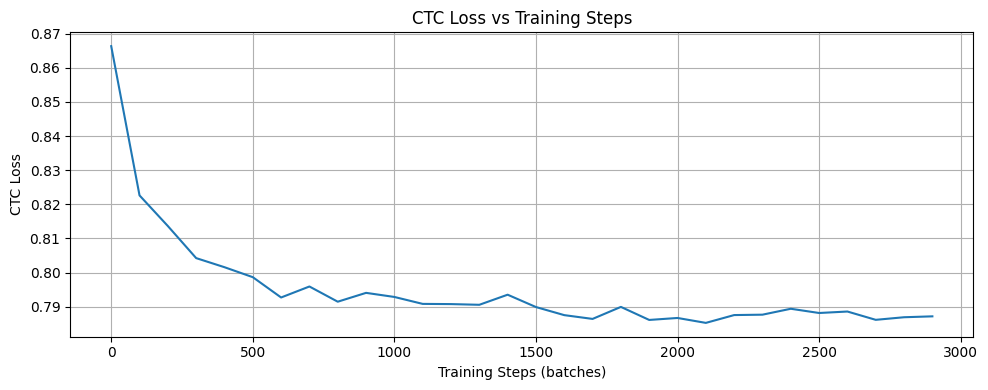

In [18]:
# Evaluation happens every 100 batches
eval_interval = 100
steps = np.arange(len(stats['testLoss'])) * eval_interval

# Plot CTC Loss
plt.figure(figsize=(10, 4))
plt.plot(steps, stats['testLoss'])
plt.xlabel('Training Steps (batches)')
plt.ylabel('CTC Loss')
plt.title('CTC Loss vs Training Steps')
plt.grid(True)
plt.tight_layout()
plt.show()

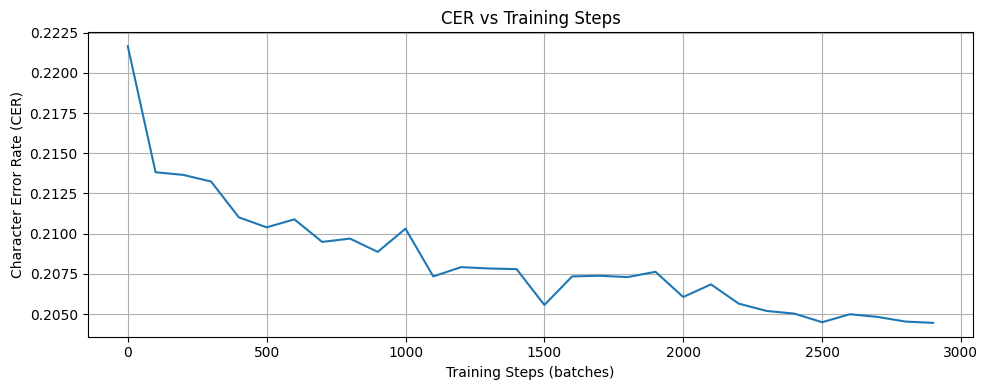

In [19]:
# Plot CER
plt.figure(figsize=(10, 4))
plt.plot(steps, stats['testCER'])
plt.xlabel('Training Steps (batches)')
plt.ylabel('Character Error Rate (CER)')
plt.title('CER vs Training Steps')
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
for i, cer in enumerate(stats['testCER']):
    print(f'Step {i * eval_interval}: CER = {cer}')

Step 0: CER = 0.9128389253435681
Step 100: CER = 0.8298047955098841
Step 200: CER = 0.6184639511369733
Step 300: CER = 0.5375345631628905
Step 400: CER = 0.49614130659073086
Step 500: CER = 0.4523544220213776
Step 600: CER = 0.421691221988362
Step 700: CER = 0.4119516322066774
Step 800: CER = 0.3857455325822294
Step 900: CER = 0.3817423961041641
Step 1000: CER = 0.3665552391564525
Step 1100: CER = 0.35124427386405843
Step 1200: CER = 0.3399364450497297
Step 1300: CER = 0.33457141678015767
Step 1400: CER = 0.32388262968924103
Step 1500: CER = 0.3166192068012051
Step 1600: CER = 0.31422557880401136
Step 1700: CER = 0.30560026412446867
Step 1800: CER = 0.3012257026123561
Step 1900: CER = 0.2955717882051917
Step 2000: CER = 0.2933845074491354
Step 2100: CER = 0.2876480541455161
Step 2200: CER = 0.28021955346457017
Step 2300: CER = 0.2794354339482481
Step 2400: CER = 0.2801782840163427
Step 2500: CER = 0.26854029961619413
Step 2600: CER = 0.26903553299492383
Step 2700: CER = 0.2623911518303

### Experiment 1: Baseline, batchsize = 16, default
Reach $CER < 0.3$ at 3400 Epoch
Best $CER = 0.2223$. Final $CER 0.2228$.

### Experiment 2: Data log transform, batchsize = 16, default
Reach $CER < 0.3$ at 3100 Epoch
Best $CER = 0.2211$. Final $CER 0.2219$.

### Experiment 3: Data log transform, reduce lr 0.02 to 0.001, further train for 3000 batches.
Best $CER = 0.2044$. Final $CER 0.2044$.

### Experiment 4: Data log transform, Adam with small $\epsilon=1e-5$, learning rate reduces to 1e-4 to 1e-5
Reach $CER < 0.3$ at 1900 Epoch
Best $CER = 0.1870$. Final $CER 0.1881$.

### Experiment 5: continue on ex4, further train 3000 batches, lr reduce to 1e-5 to 5e-7
Best $CER = 0.1836$. Final $CER 0.1836$.

